# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [9]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20251107023918,2025-11-07,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20251107023918,2025-11-07,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,f,5,5,0,0,2.30
2,5651579,https://www.airbnb.com/rooms/5651579,20251107023918,2025-11-07,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.77,4.64,NaN,f,2,1,1,0,2.95
3,6623339,https://www.airbnb.com/rooms/6623339,20251107023918,2025-11-07,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,5,5,0,0,2.62
4,9005989,https://www.airbnb.com/rooms/9005989,20251107023918,2025-11-07,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,f,1,1,0,0,5.53


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

### In your markdown:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?



Top missing columns:
license                         478
calendar_updated                478
neighbourhood_group_cleansed    478
neighbourhood                   291
neighborhood_overview           291
host_about                      230
host_location                   125
last_review                      68
reviews_per_month                68
first_review                     68
dtype: int64


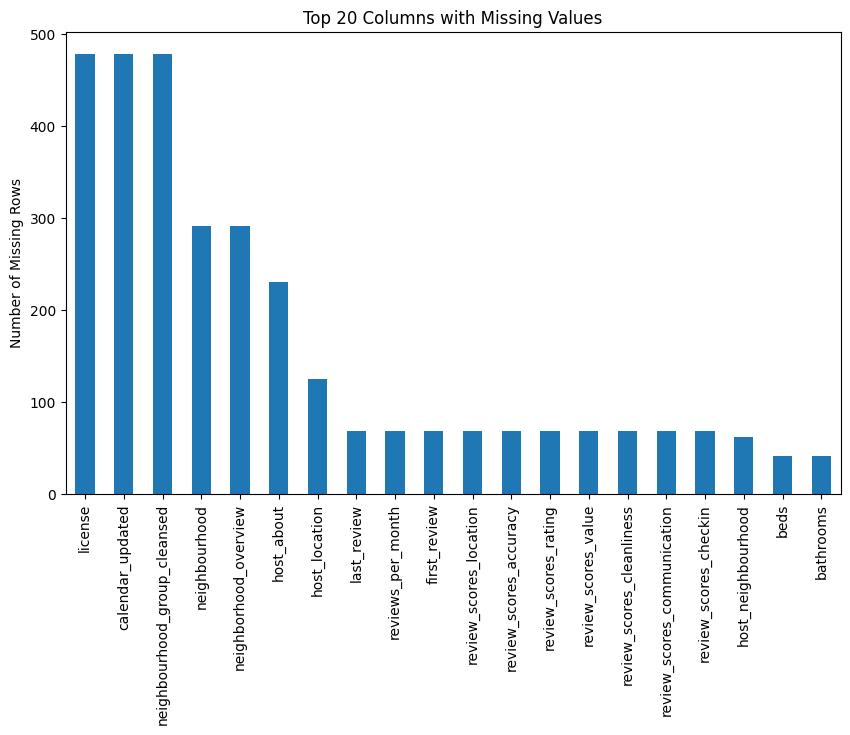

In [11]:
from itertools import count
# Add code here 🔧
missing_counts = df.isnull().sum().sort_values(ascending=False)
print("Top missing columns:")
print(missing_counts.head(10))

plt.figure(figsize=(10, 6))
missing_counts.head(20).plot(kind='bar')
plt.title('Top 20 Columns with Missing Values')
plt.ylabel('Number of Missing Rows')
plt.show()

### ✍️ Your Response: 🔧
1. top three are license, calendar_updated, neighbourhood_group_cleansed

2. I think that license will cause the most issues

3. Calendar_updated and neighbourhood_group_cleansed


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

### In Your Response:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?



In [12]:
# Add code here 🔧
cols_to_drop = ['license', 'calendar_updated', 'neighbourhood_group_cleansed']
df = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {df.shape[1]}")
df.head()

Remaining columns: 76


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20251107023918,2025-11-07,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.22,4.56,3.22,3.67,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20251107023918,2025-11-07,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.85,4.81,4.82,4.78,f,5,5,0,0,2.30
2,5651579,https://www.airbnb.com/rooms/5651579,20251107023918,2025-11-07,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.81,4.88,4.77,4.64,f,2,1,1,0,2.95
3,6623339,https://www.airbnb.com/rooms/6623339,20251107023918,2025-11-07,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.83,4.70,4.80,4.72,f,5,5,0,0,2.62
4,9005989,https://www.airbnb.com/rooms/9005989,20251107023918,2025-11-07,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.95,4.93,4.87,4.77,f,1,1,0,0,5.53


### ✍️ Your Response: 🔧
1. License, calendar updates, and neighbourhood group cleansed

2. these are not useful because they are almost all the way empty and you can't make decisions on empty data

3. leaving them in could cause errors in learning models that can't handle null values



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

### In your response:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

In [15]:
# Your code for converting column data types 🔧
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

df['bedrooms'] = df['bedrooms'].fillna(0)
df['beds'] = df['beds'].fillna(0)

print(df[['review_scores_rating', 'bedrooms', 'beds']].isnull().sum())

review_scores_rating    0
bedrooms                0
beds                    0
dtype: int64


### ✍️ Your Response: 🔧
1. cleaned review score rating, bedrooms, and beds

2. for the review scored i used median because it takes a typical value witout going extreme high or low. For bedrooms and beds I put 0 as a placeholder.

3. Filling bedrooms with 0 is risky because it might not mean studio for some of them. it could make it seem like housing is smaller than it actually is.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

### In Your Response: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?


count     437.000000
mean      113.693364
std        98.820114
min        24.000000
25%        68.000000
50%        94.000000
75%       122.000000
max      1078.000000
Name: price, dtype: float64


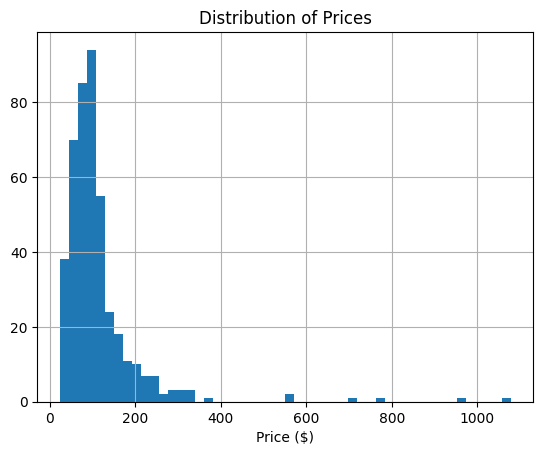

In [16]:
# Clean or adjust your dataset 🔧
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

print(df['price'].describe())

df['price'].hist(bins=50)
plt.title('Distribution of Prices')
plt.xlabel('Price ($)')
plt.show()

### ✍️ Your Response: 🔧
1. fixed price column

2. used .str.replace() to get rid of dollar signs and commas and used .astype(float) to convert text into numerical format that python can calculate

3. Its a number so we can actually calculate and run plots.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

### In your markdown:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?


In [18]:
# Add code here 🔧
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")

id_duplicates = df['id'].duplicated().sum()
print(f"Duplicate Listing IDs: {id_duplicates}")

df = df.drop_duplicates(subset='id')
print("Duplicates removed.")

Exact duplicate rows: 0
Duplicate Listing IDs: 0
Duplicates removed.


### ✍️ Your Response: 🔧 🔧
1.I checked for duplicates rows and IDs and the count was 0 so everything was unique

2. I used id column to identify but since there were no duplicates nothing really had to be dropped.

3. Risky because there can be more supply seemingly when there is not.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [20]:
# export csv here 🔧
df.to_csv('cleaned_airbnb_data_6.csv', index=False)
print("File saved")

File saved


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### In your markdown:
1. What was the most surprising or challenging part of cleaning this dataset?
2. How did you decide which data to drop, fix, or keep?
3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most suprising part was how much bad data was in the file. columns were all the way empty. It was also hard choosing how to handle missing bedroom counts.  
2. I dropped columns that were mostly empty like license. They dont offer value we can compute. I kept columns like price and review score because they are important for making business decisions.   
3. Price analyst would benefit the most. After working with dollar signs and price data they can now use everything fully.   
4. I would look at amenities. Right now it is just a lot of text but I bet there are come connections between those and reviews.  
5. This is related to my learning outcome of learning python in some degree. Cleaning isn't just a chore, you actually need to do it to visualize.   


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [22]:
!jupyter nbconvert --to html "assignment_06_rosolowski_evan.ipynb"

[NbConvertApp] Converting notebook assignment_06_rosolowski_evan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 428128 bytes to assignment_06_rosolowski_evan.html
